# WorkforceIQ - Attrition Prediction & Explainable AI 

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
import plotly.express as px
import shap


In [7]:
# Load dataset
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")


In [8]:
# Workforce Health Score
df["WorkforceHealthScore"] = (
    df["JobSatisfaction"]
    + df["WorkLifeBalance"]
    + df["EnvironmentSatisfaction"]
    + df["JobInvolvement"]
) / 16 * 100

# Attrition flag
df["AttritionFlag"] = df["Attrition"].map({"No": 0, "Yes": 1})


In [9]:
# Feature selection
drop_cols = [
    "Attrition",
    "AttritionFlag",
    "EmployeeCount",
    "EmployeeNumber",
    "StandardHours",
    "Over18"
]

X = df.drop(columns=drop_cols)
y = df["AttritionFlag"]


In [10]:
# Numerical and categorical features
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()


C:\Users\Welcome\AppData\Local\Temp\ipykernel_19896\4173422797.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [12]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)


In [13]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [14]:
# XGBoost model with imbalance handling
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5,
    random_state=42,
    eval_metric="logloss"
)


In [16]:
# Training pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Age','BusinessTravel','DailyRate',...,'YearsSinceLastPromotion', 'YearsWithCurrManager','WorkforceHealthScore']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [17]:
# Probability predictions
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Custom threshold for better recall
y_pred = (y_prob >= 0.30).astype(int)


In [18]:
# Model evaluation
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))


Accuracy : 0.8129
Precision: 0.4167
Recall   : 0.4255
F1 Score : 0.4211
ROC AUC  : 0.7762


In [19]:
# Classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.89      0.89       247
           1       0.42      0.43      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[219,  28],
       [ 27,  20]])

In [21]:
# Confusion matrix visualization
fig = px.imshow(
    cm,
    text_auto=True,
    title="Attrition Prediction Confusion Matrix"
)

fig.show()


In [22]:
# Feature names for explainability
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()


In [23]:
# Standalone model for SHAP
model.fit(X_train_transformed, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)


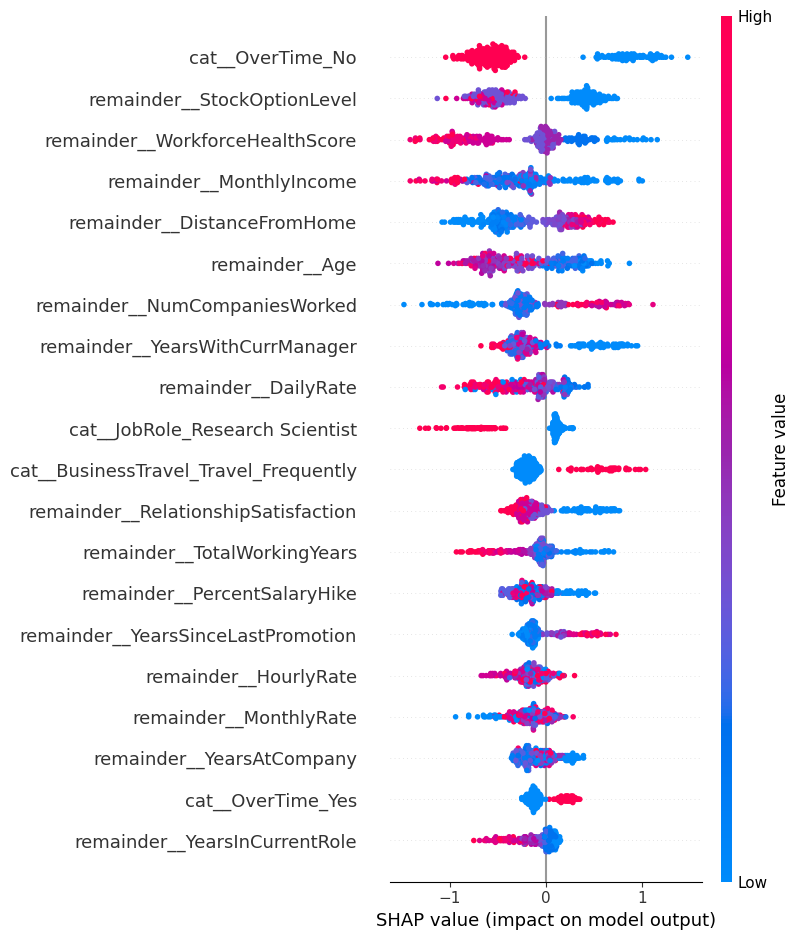

In [24]:
# Global SHAP summary
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)


In [25]:
# Feature importance
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
).head(15)

importance


,Feature,Importance
27,cat__OverTime_Yes,0.064533
35,remainder__JobLevel,0.051152
21,cat__JobRole_Sales Executive,0.045762
26,cat__OverTime_No,0.036741
43,remainder__StockOptionLevel,0.035835
51,remainder__WorkforceHealthScore,0.031174
50,remainder__YearsWithCurrManager,0.026407
20,cat__JobRole_Research Scientist,0.025770
28,remainder__Age,0.023329
0,cat__BusinessTravel_Non-Travel,0.023285


In [26]:
# Top attrition drivers
fig = px.bar(
    importance,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top Attrition Drivers"
)

fig.show()


In [27]:
# Save trained model

import joblib

joblib.dump(
    pipeline,
    "../models/attrition_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [28]:
importance.head(10)

,Feature,Importance
27,cat__OverTime_Yes,0.064533
35,remainder__JobLevel,0.051152
21,cat__JobRole_Sales Executive,0.045762
26,cat__OverTime_No,0.036741
43,remainder__StockOptionLevel,0.035835
51,remainder__WorkforceHealthScore,0.031174
50,remainder__YearsWithCurrManager,0.026407
20,cat__JobRole_Research Scientist,0.025770
28,remainder__Age,0.023329
0,cat__BusinessTravel_Non-Travel,0.023285
